# OVERVIEW

This project serves as analysis of the associated src .py files

## *IMPORTS*

Script created in trading_bot project when encountering import issues due to notebook files and working in a different directory. same script added across every project. Also changed the names of plotting files to match the project name, as python automatically was chosing the first option when called. 

In [1]:
import sys
from pathlib import Path
if not globals().get("_TRADING_PORTFOLIO_PATHS_READY"):
    _HERE = (
        Path(__file__).resolve().parent
        if "__file__" in globals()
        else Path.cwd().resolve()
    )
    _PROJECTS = (
        "past_market_analysis",
        "technical_analysis",
        "options_pricing",
        "time_series_forecasting",
        "portfolio_construction",
        "ml_fundamentals",
        "ml_trading_signals",
        "risk_management",
        "trading_bot",
    )
    _REPO_ROOT = next(
        (
            directory
            for directory in (_HERE, *_HERE.parents)
            if all((directory / project).is_dir() for project in _PROJECTS)
        ),
        None,
    )
    if _REPO_ROOT is None:
        raise RuntimeError(
            "Could not locate the trading_portfolio repository root."
        )
    _SRC_PATHS = [
        str((_REPO_ROOT / project / "src").resolve())
        for project in _PROJECTS
    ]
    sys.path.extend(path for path in _SRC_PATHS if path not in sys.path)
    _TRADING_PORTFOLIO_PATHS_READY = True


In [2]:
import sys

from data_loader import fetch_price_data, save_data, load_data
from analysis import compute_returns, summary_statistics, normality_test, rolling_stats, compare_assets
from plotting_past_market_analysis import plot_price_history, plot_returns_analysis, plot_qq

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

/Users/oscarlewis/Desktop/python/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


## **Analysis**

This project focuses on analysis of financial markets. 

In [3]:

ticker = "SOL-USD"
df = fetch_price_data(ticker, period="2y", interval="1d") #collect data on the past 2years, with each data point being a day apart
save_data(df, ticker)
df.head() #look at first values logged (i.e first 5 days 2 years ago)

Saved to ../data/SOL_USD.csv


Price,Close,High,Low,Open,Volume
Date,,,,,
2024-08-20,143.167740,148.648605,141.360703,144.346848,2124392770
2024-08-21,142.709610,144.156296,139.266541,142.333038,1923259439
2024-08-22,143.257935,144.813217,140.934402,142.709610,1368400829
2024-08-23,153.107086,153.771240,143.164780,143.257935,2560976300
2024-08-24,160.731750,162.169327,152.152084,153.108337,2749419604


In [4]:
#compute various statistics of the ticker over the same period, daily
df = compute_returns(df) 
df = rolling_stats(df, window=30)
df.tail() #look at most recent values

Price,Close,High,Low,Open,Volume,Return,Log_Return,Rolling_Mean_30,Rolling_Vol_30
Date,,,,,,,,,
2026-08-16,74.539017,75.599602,74.204208,75.272400,754939968,-0.009742,-0.009790,-0.000091,0.249946
2026-08-17,75.944069,76.119041,74.398689,74.539024,1367560466,0.018850,0.018674,0.000338,0.255385
2026-08-18,77.031204,77.281456,75.185989,75.943588,1532779241,0.014315,0.014213,0.000420,0.256447
2026-08-19,85.374481,86.897247,76.618996,77.031548,4534447560,0.108310,0.102837,0.003403,0.402064
2026-08-20,86.629997,87.850548,84.127174,85.358650,6023869440,0.014706,0.014599,0.003758,0.403396


In [5]:
#print key statistics into a table
stats_dict = summary_statistics(df)
for key, val in stats_dict.items():
    print(f"{key}: {float(val):.4f}")   


mean_daily_return: 0.0001
std_daily_return: 0.0402
annualised_return: 0.0292
annualised_vol: 0.6381
sharpe_ratio: 0.0458
skewness: 0.3158
kurtosis: 3.8369
max_drawdown: -0.7625
var_95: -0.0590


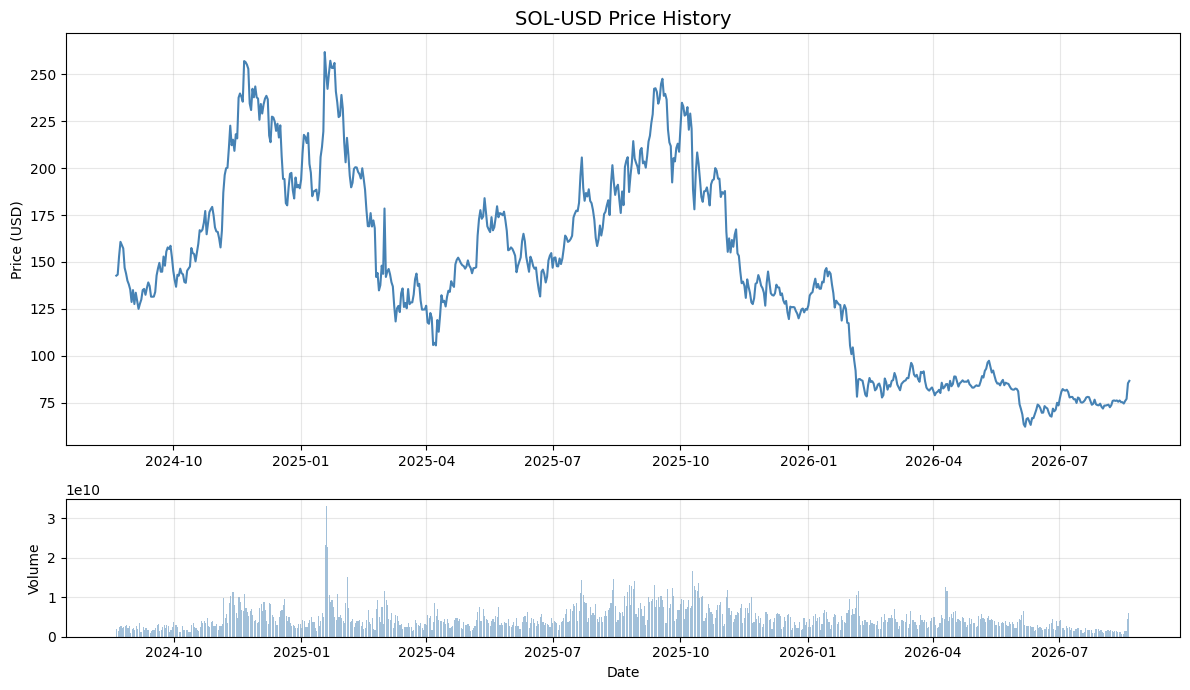

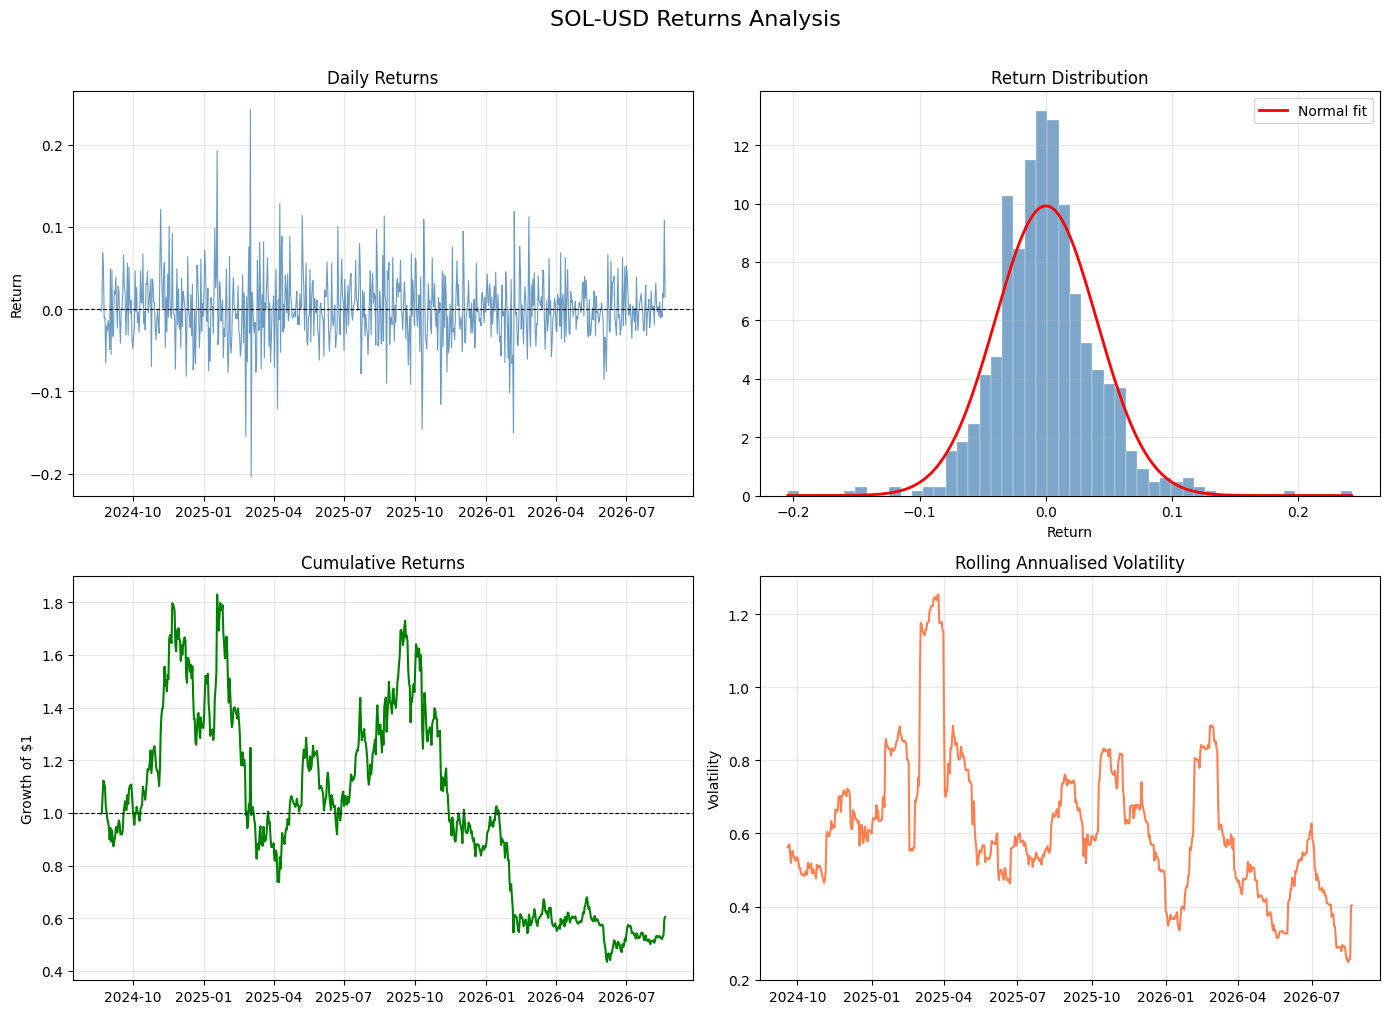

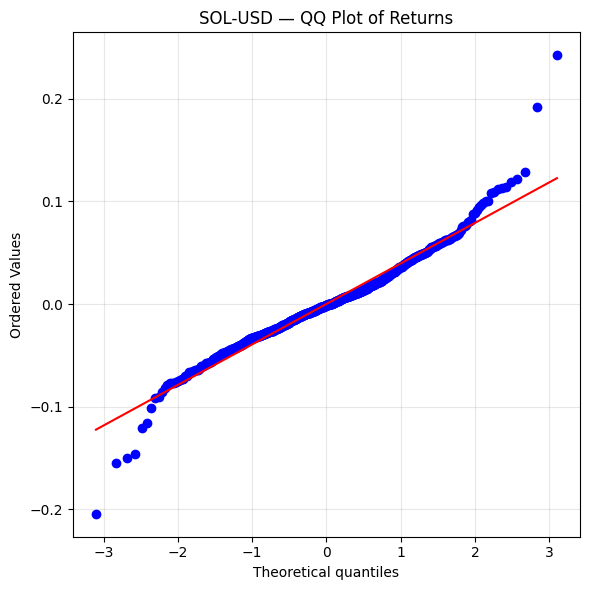

In [6]:
#plot price history and statistical distrubutions of SOL over the past 2 years
plot_price_history(df, ticker)
plot_returns_analysis(df, ticker)
plot_qq(df, ticker)

There is a lot to digest from these plots. See from the volatility plot that it is a very volatile ticker, as expected with a cryptocurrency. The returns distrubution does not look very normal, and the 'fat tails' on the QQ plot imply the same. This is tested statistically below:

In [7]:
norm_test = normality_test(df)
print(f"Stastistic: {norm_test['statistic']:.4f}")
print(f"p-value: {norm_test['p_value']:.4f}")
print(f"Normal? : {norm_test['is_normal']}")

Stastistic: 82.5976
p-value: 0.0000
Normal? : False


See the p-value is  zero, meaning it is very significant, confirming suspicisions about SOL returns not following a normal distrubution.

Now test across multiple tickers

In [8]:
tickers = [ 
    "BTC-USD",
    "SOL-USD",
    "ETH-USD",
    "AAPL",
    "SPY",
    "GLD"
]

In [9]:
ranking = compare_assets(tickers, period="2y")
ranking.round(4)

fetchingBTC-USD...
fetchingSOL-USD...
fetchingETH-USD...
fetchingAAPL...
fetchingSPY...
fetchingGLD...


,mean_daily_return,std_daily_return,annualised_return,annualised_vol,sharpe_ratio,skewness,kurtosis,max_drawdown,var_95
ticker,,,,,,,,,
GLD,0.0013,0.0150,0.3157,0.2380,1.3264,-0.8417,5.7399,-0.2640,-0.0227
SPY,0.0007,0.0105,0.1853,0.1663,1.1140,1.1402,22.3058,-0.1876,-0.0154
AAPL,0.0009,0.0181,0.2159,0.2878,0.7502,0.6144,12.1332,-0.3336,-0.0272
BTC-USD,0.0005,0.0234,0.1351,0.3713,0.3640,0.1761,4.1487,-0.5306,-0.0357
ETH-USD,0.0005,0.0366,0.1237,0.5803,0.2132,0.5197,4.1771,-0.6761,-0.0533
SOL-USD,0.0001,0.0402,0.0292,0.6381,0.0458,0.3158,3.8369,-0.7625,-0.0590


The table above is sorted by Sharpe ratio, which measures the returns of a ticker per unit of risk you take on. This gives a gauge as to how 'reliable' a ticker is.

In [10]:
print("=== Asset Ranking by Sharpe Ratio ===\n")
for ticker, row in ranking.iterrows():
    print(f"{ticker:10s} | Sharpe: {float(row['sharpe_ratio']):6.3f} | "
    f"Ann. Return: {float(row['annualised_return']):7.3f} | "
    f"Volatility: {float(row['annualised_vol']):6.3f} | "
    f"MAX DD: {float(row['max_drawdown']):7.3f}")

=== Asset Ranking by Sharpe Ratio ===

GLD        | Sharpe:  1.326 | Ann. Return:   0.316 | Volatility:  0.238 | MAX DD:  -0.264
SPY        | Sharpe:  1.114 | Ann. Return:   0.185 | Volatility:  0.166 | MAX DD:  -0.188
AAPL       | Sharpe:  0.750 | Ann. Return:   0.216 | Volatility:  0.288 | MAX DD:  -0.334
BTC-USD    | Sharpe:  0.364 | Ann. Return:   0.135 | Volatility:  0.371 | MAX DD:  -0.531
ETH-USD    | Sharpe:  0.213 | Ann. Return:   0.124 | Volatility:  0.580 | MAX DD:  -0.676
SOL-USD    | Sharpe:  0.046 | Ann. Return:   0.029 | Volatility:  0.638 | MAX DD:  -0.763


See from the selection of tickers that gold was the most reliable over the past 2 years. Due to its volatility, it is not too surprising to see the cryptocurrencies perform poorly by this metric, especially due to poor performance over the time period.